In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd

/Users/nikos/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/nikos/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from CP.scores import RegressionScores
from CP.regressor import SplitConformalRegressor

In [3]:
data = fetch_california_housing()
X = data.data
y = data.target

In [4]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
len(X)

20640

In [3]:
# ============================================================
# Load and split California Housing
# ============================================================

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print("Train shape :", X_train.shape)
print("Calib shape :", X_calib.shape)
print("Test shape  :", X_test.shape)
print("Target range:", y.min(), y.max())


Train shape : (12384, 8)
Calib shape : (4128, 8)
Test shape  : (4128, 8)
Target range: 0.14999 5.00001


In [4]:
# ============================================================
# Configurations for the three score types
# ============================================================

configs = {
    "residual": {
        "score": RegressionScores(score_type="residual"),
        "kwargs": {
            "point_model": RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        }
    },
    "scaled_residual": {
        "score": RegressionScores(score_type="scaled_residual"),
        "kwargs": {
            "point_model": RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            ),
            "scale_model": RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        }
    },
    "cqr": {
        "score": RegressionScores(score_type="cqr"),
        "kwargs": {
            "lower_model": GradientBoostingRegressor(
                loss="quantile",
                alpha=0.05,
                random_state=42
            ),
            "upper_model": GradientBoostingRegressor(
                loss="quantile",
                alpha=0.95,
                random_state=42
            )
        }
    }
}

In [5]:
# ============================================================
# Fit all conformal regressors and store results
# ============================================================

results = {}

for name, cfg in configs.items():
    cp = SplitConformalRegressor(
        score=cfg["score"],
        alpha=0.1,
        **cfg["kwargs"]
    )

    cp.fit(X_train, y_train, X_calib, y_calib)

    y_pred = cp.predict(X_test)
    lower, upper = cp.predict_interval(X_test)

    coverage = np.mean((y_test >= lower) & (y_test <= upper)) # What percent is in the interval
    avg_width = np.mean(upper - lower)

    results[name] = {
        "cp": cp,
        "y_pred": y_pred,
        "lower": lower,
        "upper": upper,
        "coverage": coverage,
        "avg_width": avg_width,
        "q_hat": cp.q_hat_
    }

    print(f"\n=== {name.upper()} ===")
    print(f"q_hat    : {cp.q_hat_:.6f}")
    print(f"coverage : {coverage:.6f}")
    print(f"avg width: {avg_width:.6f}")




=== RESIDUAL ===
q_hat    : 0.788895
coverage : 0.899709
avg width: 1.577790

=== SCALED_RESIDUAL ===
q_hat    : 5.367031
coverage : 0.890988
avg width: 1.348742

=== CQR ===
q_hat    : 0.021039
coverage : 0.901890
avg width: 1.808779


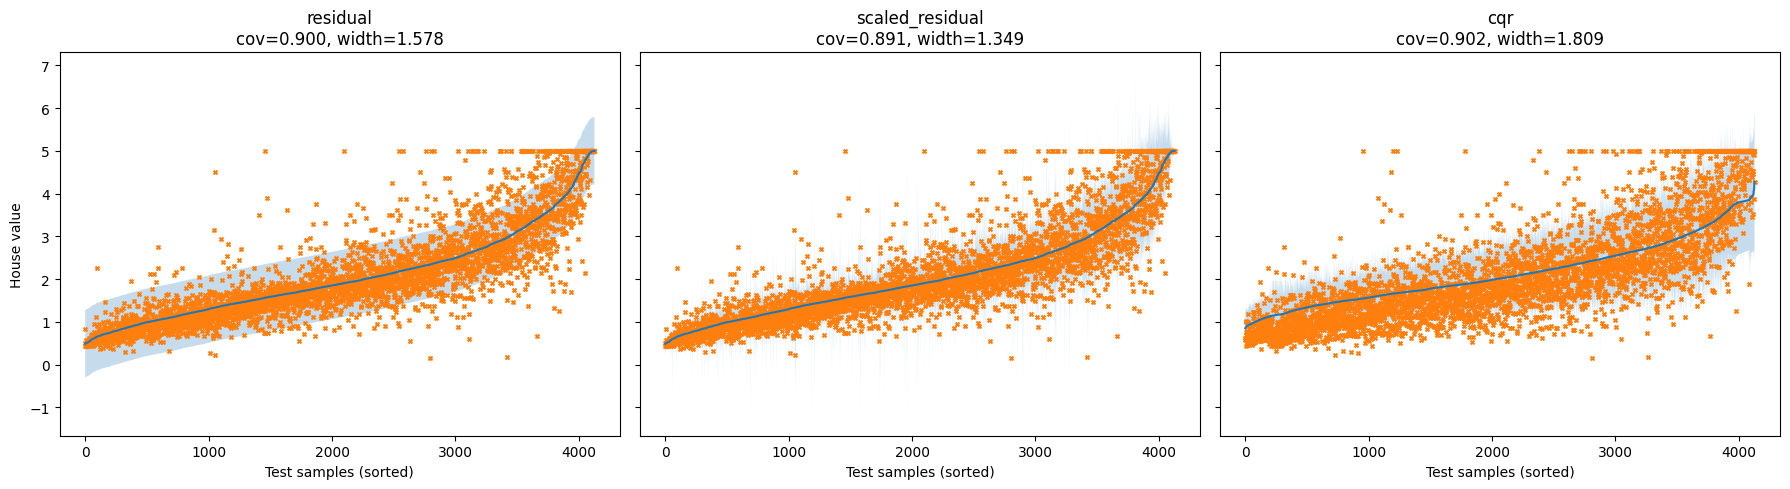

In [6]:
# ============================================================
# Plot prediction intervals side by side
# ============================================================

score_types = ["residual", "scaled_residual", "cqr"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, score_type in zip(axes, score_types):
    y_pred = results[score_type]["y_pred"]
    lower = results[score_type]["lower"]
    upper = results[score_type]["upper"]

    idx = np.argsort(y_pred)

    y_pred_sorted = y_pred[idx]
    y_test_sorted = y_test[idx]
    lower_sorted = lower[idx]
    upper_sorted = upper[idx]

    x = np.arange(len(y_pred_sorted))

    ax.fill_between(x, lower_sorted, upper_sorted, alpha=0.25)
    ax.plot(x, y_pred_sorted, linewidth=1.5)
    ax.scatter(x, y_test_sorted, s=8, marker="x")

    ax.set_title(
        f"{score_type}\n"
        f"cov={results[score_type]['coverage']:.3f}, "
        f"width={results[score_type]['avg_width']:.3f}"
    )
    ax.set_xlabel("Test samples (sorted)")

axes[0].set_ylabel("House value")
plt.tight_layout()
plt.show()

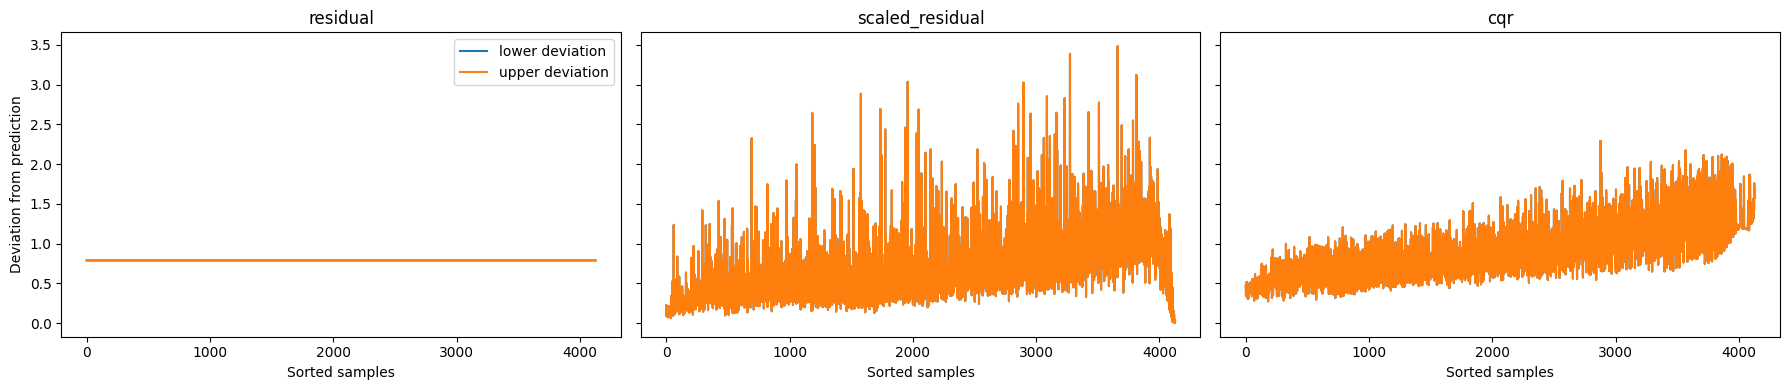

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, score_type in zip(axes, ["residual", "scaled_residual", "cqr"]):

    y_pred = results[score_type]["y_pred"]
    lower = results[score_type]["lower"]
    upper = results[score_type]["upper"]

    lower_dev = y_pred - lower
    upper_dev = upper - y_pred

    idx = np.argsort(y_pred)

    ax.plot(lower_dev[idx], label="lower deviation")
    ax.plot(upper_dev[idx], label="upper deviation")

    ax.set_title(score_type)
    ax.set_xlabel("Sorted samples")

axes[0].set_ylabel("Deviation from prediction")
axes[0].legend()

plt.tight_layout()
plt.show()

In [ ]:
evaluator = ClassificationConformalEvaluator()
results = evaluator.evaluate(cp, X_test, y_test)

In [ ]:
# ============================================================
# Length of calibration dataset n>=10000
# ============================================================